<a href="https://colab.research.google.com/github/davinalifianda123/pengolahan_citra_smt4/blob/main/Jobsheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

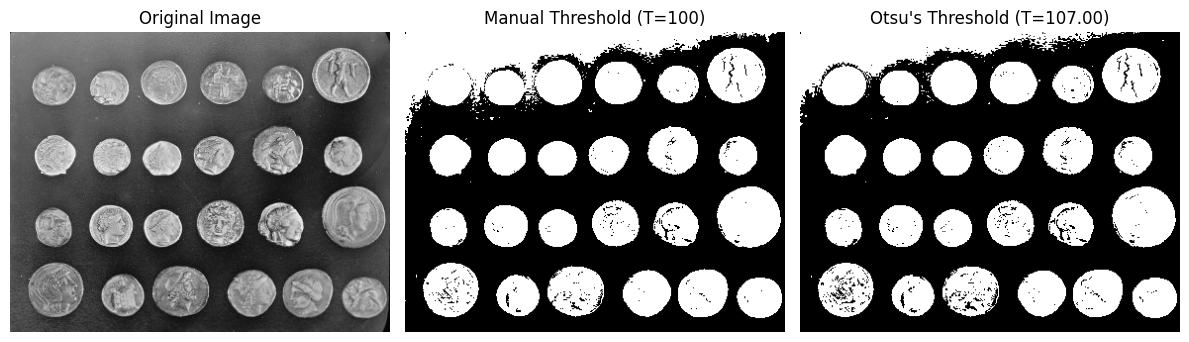


Nilai threshold Otsu yang ditemukan: 107


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

# 1. Memuat citra contoh (coins)
image_coins = data.coins()  # Citra sudah dalam format grayscale

# 2. Thresholding Global Manual
# Menentukan nilai ambang manual
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Plot gambar asli
ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Plot hasil threshold manual
ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

# Plot hasil threshold Otsu
ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"\nNilai threshold Otsu yang ditemukan: {thresh_otsu}")

#Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

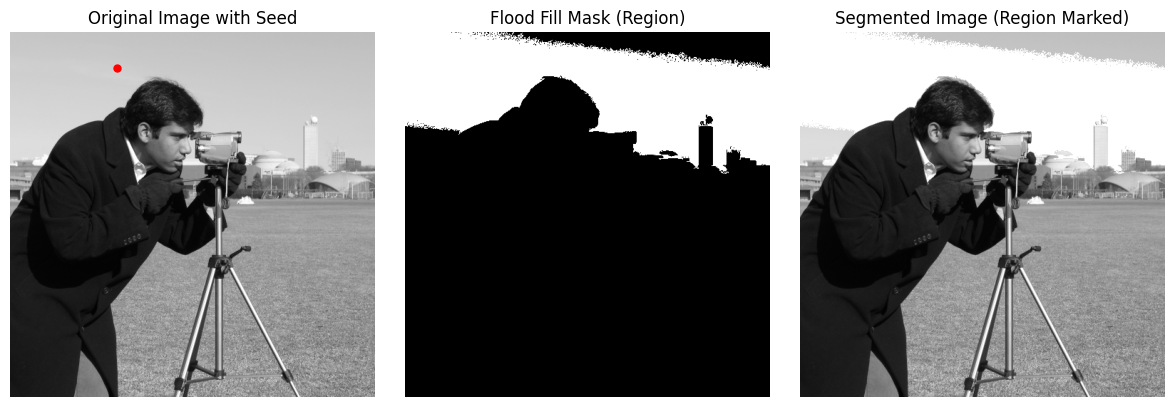

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# 1. Memuat citra contoh (camera)
image_camera = data.camera()  # Citra grayscale wajah dan latar belakang

# 2. Menentukan titik seed (benih) untuk region growing
# Memilih titik di area latar belakang (koordinat y=50, x=150)
seed_point = (50, 150)  # Format: (row, column)

# 3. Menerapkan algoritma flood fill (region growing)
# Tolerance menentukan batas perbedaan intensitas piksel yang diterima
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Membuat citra hasil segmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Memberi warna putih pada area terdeteksi

# 5. Visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Plot gambar asli dengan seed point
ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro', markersize=5)  # Menandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

# Plot mask hasil flood fill
ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

# Plot hasil segmentasi
ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

#Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

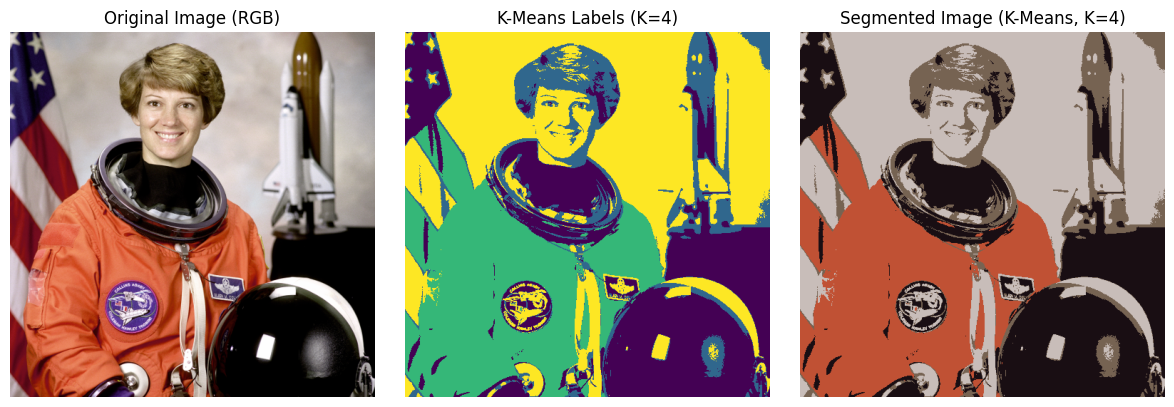

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

image_astro = data.astronaut()
image_astro_float = image_astro.astype(float) / 255.0
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_labels = pixel_labels.reshape(rows, cols)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    cluster_pixels = (pixel_labels == k)
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

segmented_image_rgb = lab2rgb(segmented_image_kmeans)

fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

#Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

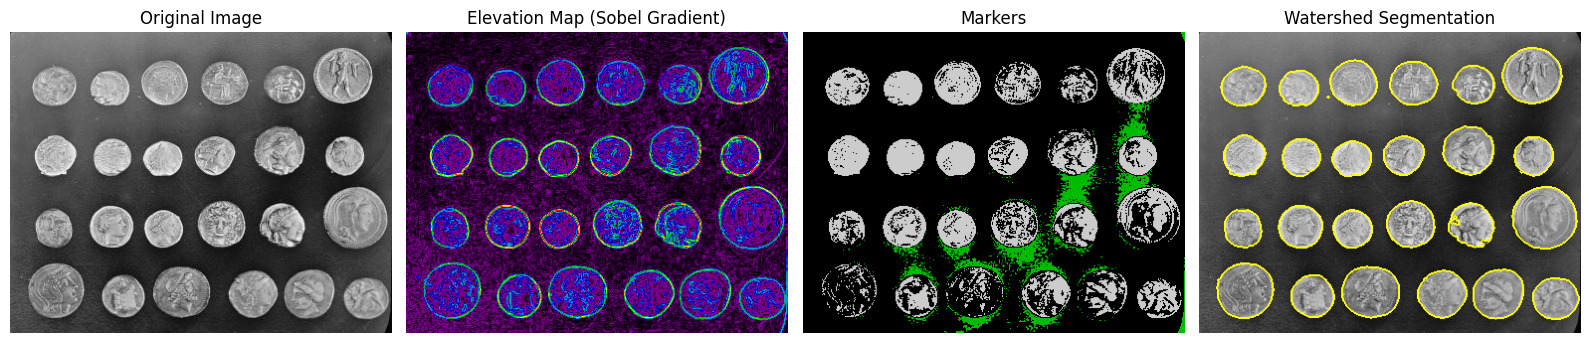

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

image_coins = data.coins()
elevation_map = filters.sobel(image_coins)

markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()


#Praktikum 5. Perbandingan Visual Hasil Segmentasi

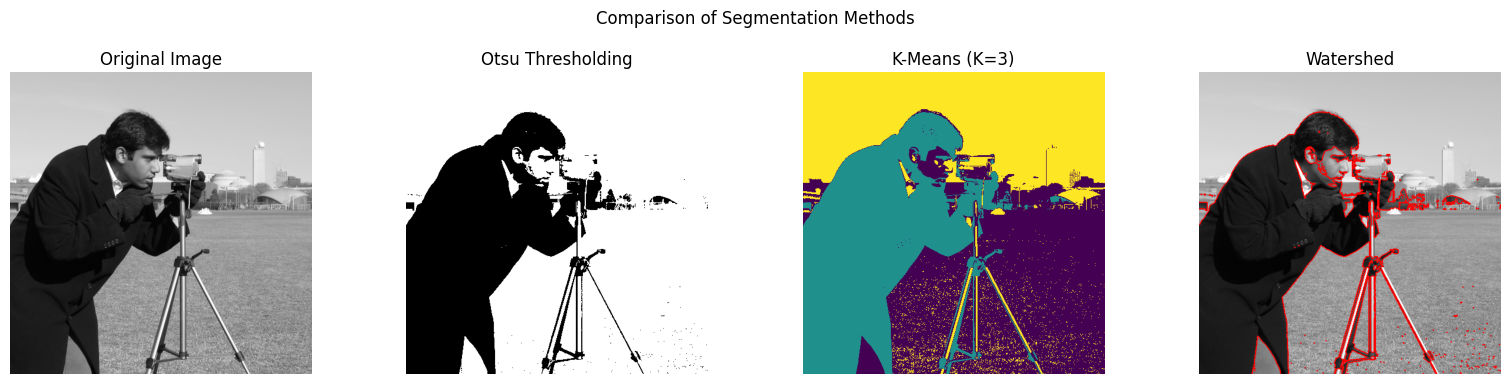

In [5]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

image = data.camera()
image_float = img_as_float(image)

thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1,0,0))
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Eksperimen Thresholding

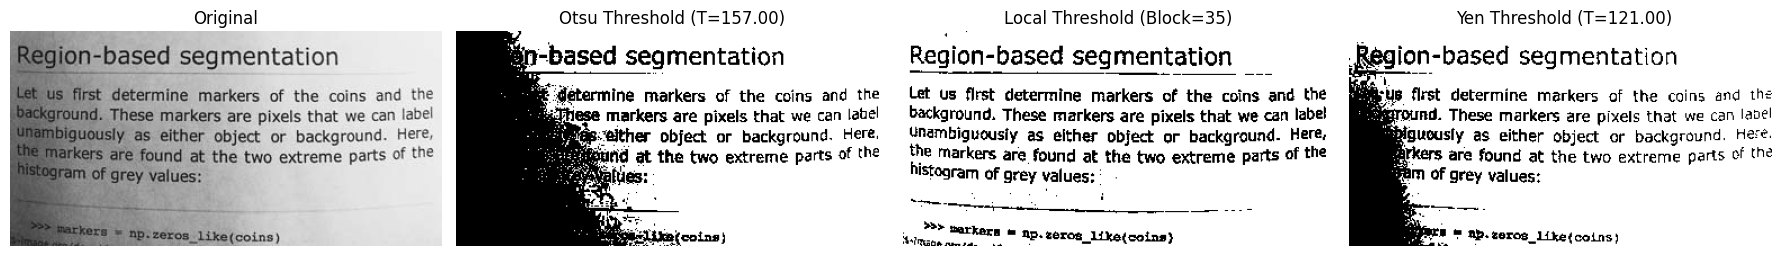

In [6]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.filters import threshold_otsu, threshold_local, threshold_yen
from skimage import img_as_ubyte
import numpy as np

# Load citra dokumen
image = data.page()
image = img_as_ubyte(image)  # pastikan dalam format 8-bit

# Thresholding Otsu
thresh_otsu = threshold_otsu(image)
binary_otsu = image > thresh_otsu

# Thresholding Local (adaptive)
block_size = 35
local_thresh = threshold_local(image, block_size, offset=10)
binary_local = image > local_thresh

# Thresholding Yen
thresh_yen = threshold_yen(image)
binary_yen = image > thresh_yen

# Visualisasi hasil
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu Threshold (T={thresh_otsu:.2f})')

ax[2].imshow(binary_local, cmap='gray')
ax[2].set_title(f'Local Threshold (Block={block_size})')

ax[3].imshow(binary_yen, cmap='gray')
ax[3].set_title(f'Yen Threshold (T={thresh_yen:.2f})')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

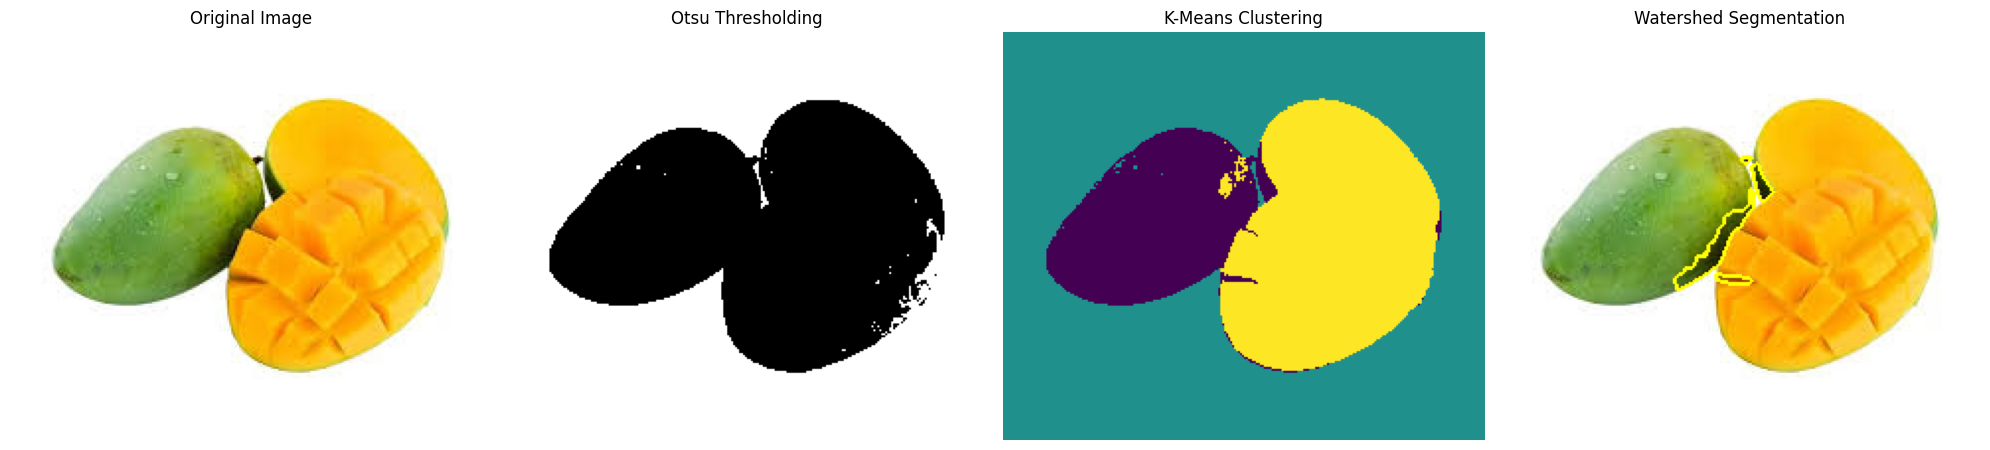

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, segmentation, morphology
from skimage.filters import threshold_otsu
from sklearn.cluster import KMeans
from scipy import ndimage as ndi
from skimage.color import rgb2gray

# Load gambar buah (misalnya jeruk dengan background polos)
image = io.imread('buah.jpeg')
image_rgb = image / 255.0  # Normalisasi
image_gray = rgb2gray(image)

# --- 1. OTSU THRESHOLDING ---
thresh_otsu = threshold_otsu(image_gray)
binary_otsu = image_gray > thresh_otsu

# --- 2. K-MEANS CLUSTERING ---
rows, cols, ch = image.shape
pixels = image_rgb.reshape((-1, 3))
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)
segmented_kmeans = labels.reshape((rows, cols))

# --- 3. WATERSHED ---
elevation_map = filters.sobel(image_gray)
markers = np.zeros_like(image_gray, dtype=np.int32)  # dtype penting
markers[image_gray < 0.3] = 1
markers[image_gray > 0.7] = 2
segmentation_ws = segmentation.watershed(elevation_map, markers)
segmented_ws_colored = segmentation.mark_boundaries(image_rgb, segmentation_ws)

# --- Visualisasi ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ax = axes.ravel()

ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title('K-Means Clustering')
ax[2].axis('off')

ax[3].imshow(segmented_ws_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()